# Подключение изначальных библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import torch
import torch.nn as nn
from google.colab import drive
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

Вход в гугл драйв, где лежит датасет скаченный из Kaggle

In [2]:
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/Colab Notebooks/go_emotions_dataset.csv'

Mounted at /content/drive


Показ первых 5 строк датасета для демонстрации его содержимого.

In [3]:
emotions_df = pd.read_csv(file_path)
emotions_df.head()

,id,text,example_very_unclear,admiration,amusement,anger,annoyance,approval,caring,confusion,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,eew5j0j,That game hurt.,False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,eemcysk,>sexuality shouldn’t be a grouping category I...,True,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,ed2mah1,"You do right, if you don't care then fuck 'em!",False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,eeibobj,Man I love reddit.,False,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,eda6yn6,"[NAME] was nowhere near them, he was by the Fa...",False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


Список всех возможных эмоций встречаемых в данном датасете

In [4]:
list_of_emotions = list(emotions_df.columns)[3:]
print(list_of_emotions)

['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']


В этом блоке кода мы выполняем предобработку текстовых данных в столбце text датасета emotions_df:
1. Приводим текст к нижнему регистру
2. Удаляем ссылки
3. Убираем HTML-теги
4. Оставляем только английские буквы и пробелы
5. Убираем лишние проблемы

In [5]:
import re

def clean_text(text):
  text = str(text).lower()
  text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
  text = re.sub(r'<.*?>', '', text)
  text = re.sub(r'[^a-zA-Z\s]', ' ', text)
  text = ' '.join(text.split())
  return text

emotions_df['text'] = emotions_df['text'].apply(clean_text)
emotions_df.head()

,id,text,example_very_unclear,admiration,amusement,anger,annoyance,approval,caring,confusion,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,eew5j0j,that game hurt,False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,eemcysk,sexuality shouldn t be a grouping category it ...,True,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,ed2mah1,you do right if you don t care then fuck em,False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,eeibobj,man i love reddit,False,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,eda6yn6,name was nowhere near them he was by the falcon,False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


Проверяем датасет, чтобы убедиться, что все поля заполнены.

In [6]:
emotions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211225 entries, 0 to 211224
Data columns (total 31 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   id                    211225 non-null  object
 1   text                  211225 non-null  object
 2   example_very_unclear  211225 non-null  bool  
 3   admiration            211225 non-null  int64 
 4   amusement             211225 non-null  int64 
 5   anger                 211225 non-null  int64 
 6   annoyance             211225 non-null  int64 
 7   approval              211225 non-null  int64 
 8   caring                211225 non-null  int64 
 9   confusion             211225 non-null  int64 
 10  curiosity             211225 non-null  int64 
 11  desire                211225 non-null  int64 
 12  disappointment        211225 non-null  int64 
 13  disapproval           211225 non-null  int64 
 14  disgust               211225 non-null  int64 
 15  embarrassment    

Суммирует данные по каждому классу "эмоций", сортируем их по убыванию и визуализируем с помощью Seaborn, добавляя подписи и оформление для наглядности.

/tmp/ipykernel_707/172708196.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=emotion_counts.index, y=emotion_counts.values, palette="pastel")


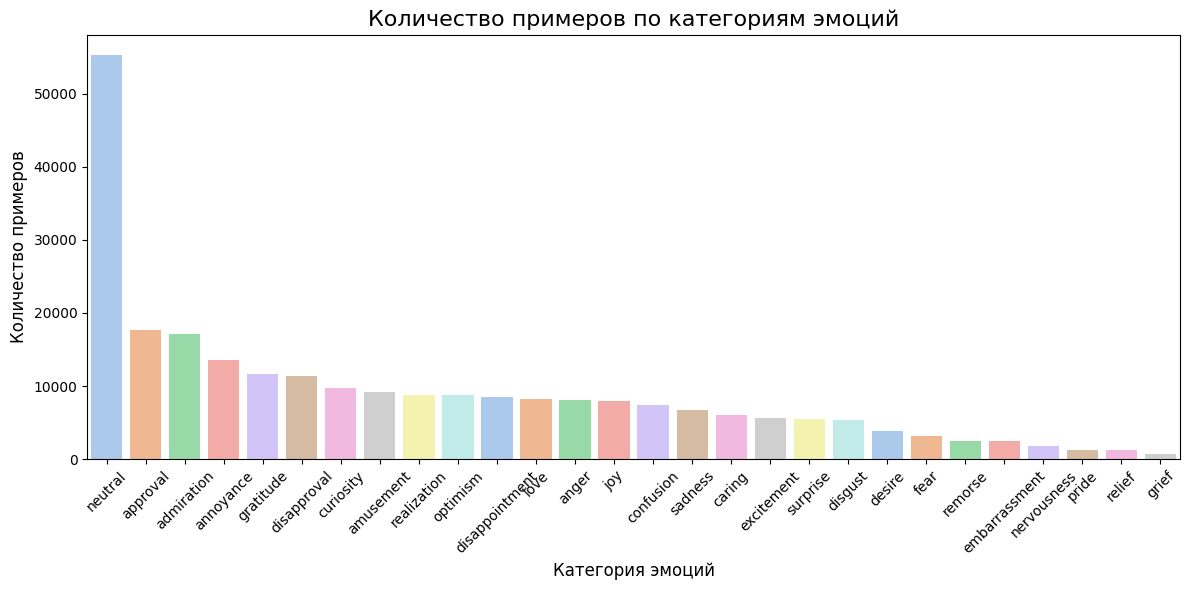

In [7]:
def plot_class_distribution_in_dataset(df, emotion_cols):
  emotion_counts = df[emotion_cols].sum().sort_values(ascending=False)
  plt.figure(figsize=(12,6))
  sns.barplot(x=emotion_counts.index, y=emotion_counts.values, palette="pastel")
  plt.title("Количество примеров по категориям эмоций", fontsize=16)
  plt.xlabel("Категория эмоций", fontsize=12)
  plt.ylabel("Количество примеров", fontsize=12)
  plt.xticks(rotation=45)
  plt.tight_layout()

plot_class_distribution_in_dataset(emotions_df, list_of_emotions)

In [8]:
def find_rows_with_multiple_emotions(df, emotions_list):
    rows_with_multiple_emotions = []
    for index, row in df.iterrows():
        active_emotions = [emotion for emotion in emotions_list if row[emotion] > 0]
        if len(active_emotions) > 1:
            rows_with_multiple_emotions.append((row['text'], active_emotions))
    return rows_with_multiple_emotions

result = find_rows_with_multiple_emotions(emotions_df, list_of_emotions)
for text, emotions in result[:3]:
    print(f"Text: {text}\nActive Emotions: {', '.join(emotions)}\n")

Text: that is odd
Active Emotions: disappointment, disgust

Text: i appreciate it that s good to know i hope i ll have to apply that knowledge one day
Active Emotions: admiration, gratitude

Text: now i m wondering on what i ve been missing out again thank you for this
Active Emotions: curiosity, gratitude



In [9]:
print(len(result))

35994


Объединяем исходные эмоции в новые категории согласно заданным группам.

In [10]:
positive = ['admiration', 'amusement', 'approval', 'caring', 'excitement',
  'gratitude', 'joy', 'love', 'optimism', 'pride', 'relief', 'desire']
negative = ['anger', 'annoyance', 'disapproval', 'disgust', 'fear', 'nervousness']
sadness = ['disappointment','embarrassment','grief','remorse','sadness']
cognition = ['confusion','curiosity','realization','surprise']
neutral = ['neutral']

types_of_emotions = {
  "positive": positive,
  "negative": negative,
  "sadness": sadness,
  "congintion": cognition,
  "neutral": neutral
}

emotion_to_type = {}
for category, emotions in types_of_emotions.items():
  for emo in emotions:
    emotion_to_type[emo] = category

for category, emotions in types_of_emotions.items():
  emotions_df[category] = emotions_df[emotions].sum(axis=1)
  emotions_df[category] = emotions_df[category].apply(lambda x: 1 if x > 0 else 0)

delete_emotions_list = [e for e in list_of_emotions if e not in ["neutral", "sadness"]]
emotions_df = emotions_df.drop(columns=delete_emotions_list)
emotions_df = emotions_df[emotions_df['example_very_unclear'] == False]
emotions_df = emotions_df.drop(columns=['id', 'example_very_unclear'])
emotions_df.head()

,text,sadness,neutral,positive,negative,congintion
0,that game hurt,1,0,0,0,0
2,you do right if you don t care then fuck em,0,1,0,0,0
3,man i love reddit,0,0,1,0,0
4,name was nowhere near them he was by the falcon,0,1,0,0,0
5,right considering it s such an important docum...,0,0,1,0,0


Проверяем датасет

In [11]:
emotions_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 207814 entries, 0 to 211223
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   text        207814 non-null  object
 1   sadness     207814 non-null  int64 
 2   neutral     207814 non-null  int64 
 3   positive    207814 non-null  int64 
 4   negative    207814 non-null  int64 
 5   congintion  207814 non-null  int64 
dtypes: int64(5), object(1)
memory usage: 11.1+ MB


Демонстрация распределения классов

/tmp/ipykernel_707/172708196.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=emotion_counts.index, y=emotion_counts.values, palette="pastel")


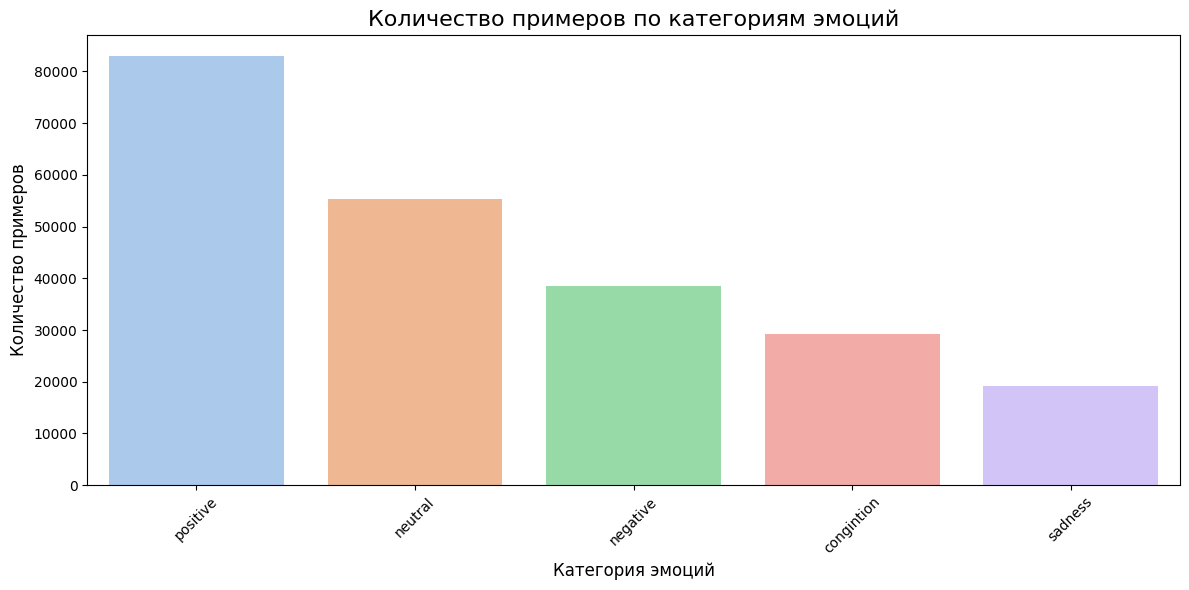

In [12]:
crt_emotions = list(emotions_df.columns)[1:]
plot_class_distribution_in_dataset(emotions_df, crt_emotions)

In [13]:
updated_result = find_rows_with_multiple_emotions(emotions_df, crt_emotions)
for text, emotions in updated_result[:3]:
    print(f"Text: {text}\nActive Emotions: {', '.join(emotions)}\n")
print(len(updated_result))

Text: that is odd
Active Emotions: sadness, negative

Text: now i m wondering on what i ve been missing out again thank you for this
Active Emotions: positive, congintion

Text: so happy for name so sad he s not here imagine this team with name instead of name ugh
Active Emotions: sadness, positive, negative

16681


Сбланасировка датасета

In [14]:
only_positive_idx = emotions_df[
    (emotions_df['positive'] == 1) &
    (emotions_df['neutral'] == 0) &
    (emotions_df['negative'] == 0) &
    (emotions_df['sadness'] == 0) &
    (emotions_df['congintion'] == 0)
].index

only_neutral_idx = emotions_df[
    (emotions_df['neutral'] == 1) &
    (emotions_df['positive'] == 0) &
    (emotions_df['negative'] == 0) &
    (emotions_df['sadness'] == 0) &
    (emotions_df['congintion'] == 0)
].index

np.random.seed(42)
drop_positive = np.random.choice(only_positive_idx, size=40000, replace=False)
drop_neutral = np.random.choice(only_neutral_idx, size=25000, replace=False)

indexes_to_drop = np.concatenate([drop_positive, drop_neutral])
emotions_df_balanced = emotions_df.drop(indexes_to_drop)
print(f"Было строк: {len(emotions_df)}")
print(f"Стало строк: {len(emotions_df_balanced)}")

Было строк: 207814
Стало строк: 142814


/tmp/ipykernel_707/172708196.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=emotion_counts.index, y=emotion_counts.values, palette="pastel")


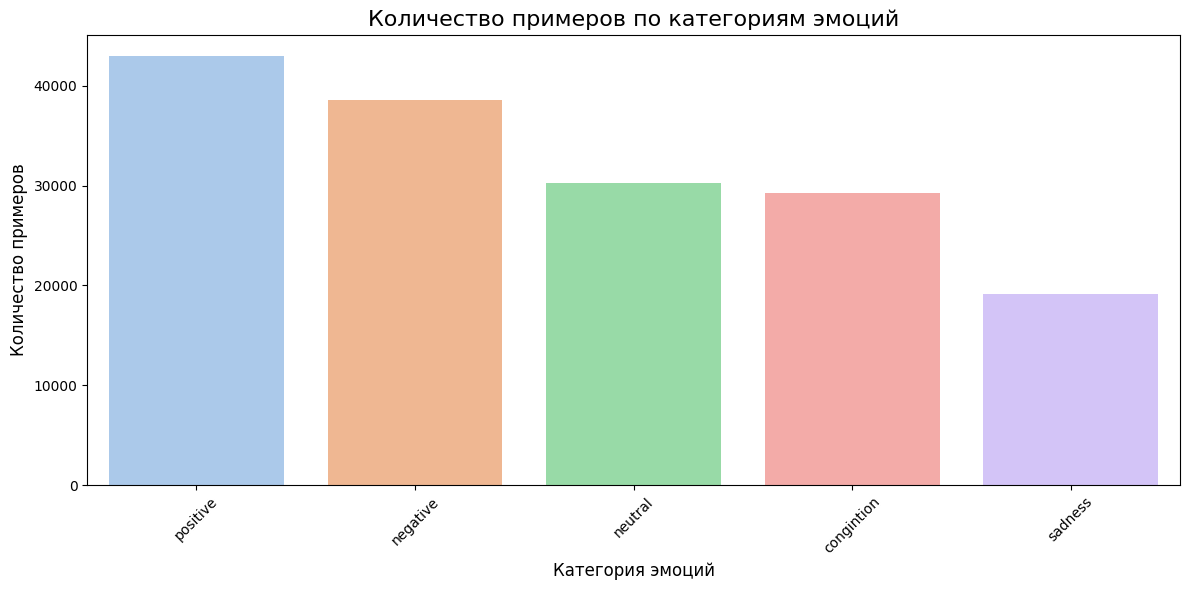

In [15]:
plot_class_distribution_in_dataset(emotions_df_balanced, crt_emotions)

Создание класса для датасета

In [16]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

class GoEmotionDataset(Dataset):
  def __init__(self, dataframe, tokenizer, max_len, label_columns):
    self.df = dataframe
    self.tokenizer = tokenizer
    self.max_len = max_len
    self.label_columns = label_columns

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    text = self.df.iloc[idx]['text']
    labels = self.df.iloc[idx][self.label_columns].values.astype(np.float32)
    encoded = self.tokenizer(
      text,
      add_special_tokens=True,
      max_length=self.max_len,
      padding='max_length',
      truncation=True,
      return_attention_mask=True,
      return_tensors='pt'
    )

    input_ids = encoded['input_ids'].squeeze(0)
    label_tensor = torch.tensor(labels, dtype=torch.float)
    attention_mask = encoded['attention_mask'].squeeze(0)

    return {
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'labels': label_tensor
    }

In [17]:
from transformers import BertModel, BertTokenizer

train_emotions, temp_emotions = train_test_split(emotions_df_balanced, test_size=0.3, random_state=42)
val_emotions, test_emotions = train_test_split(temp_emotions, test_size=0.5, random_state=24)

MAX_LEN = 32
bert_model_name = 'bert-base-uncased'
bert_model = BertModel.from_pretrained(bert_model_name)
tokenizer = BertTokenizer.from_pretrained(bert_model_name)

pretrained_embeddings = bert_model.embeddings.word_embeddings.weight.data
vocab_size, embed_dim = pretrained_embeddings.size()

print(f"Vocabulary size from BERT: {vocab_size}, Embedding dimension: {embed_dim}")
label_columns = ['sadness','neutral','positive','negative','congintion']

train_dataset = GoEmotionDataset(
  dataframe=train_emotions,
  tokenizer=tokenizer,
  max_len=MAX_LEN,
  label_columns=label_columns
)

val_dataset = GoEmotionDataset(
  dataframe=val_emotions,
  tokenizer=tokenizer,
  max_len=MAX_LEN,
  label_columns=label_columns
)

test_dataset = GoEmotionDataset(
  dataframe=test_emotions,
  tokenizer=tokenizer,
  max_len=MAX_LEN,
  label_columns=label_columns
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Vocabulary size from BERT: 30522, Embedding dimension: 768


In [18]:
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Number of classes: {len(label_columns)}")
VOCAB_SIZE = tokenizer.vocab_size
print(f"Vacabulary size: {VOCAB_SIZE}")

Training samples: 99969
Validation samples: 21422
Test samples: 21423
Number of classes: 5
Vacabulary size: 30522


Создание модели на основе BiLSTM архитектуры

In [19]:
import torch.optim as optim

class BiLSTMClassifier(nn.Module):
  def __init__(self, pretrained_embeddings, hidden_dim, num_layers, num_classes, dropout_rate=0.5):
    super(BiLSTMClassifier, self).__init__()

    self.embedding = nn.Embedding.from_pretrained(pretrained_embeddings, freeze=False, padding_idx=0)
    embed_dim = pretrained_embeddings.size(1)

    self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers,
                        batch_first=True, bidirectional=True,
                        dropout=dropout_rate)

    self.attention = nn.Linear(hidden_dim * 2, 1)

    self.dropout = nn.Dropout(dropout_rate)
    self.fc = nn.Linear(hidden_dim * 2, num_classes)

  def forward(self, x):
    embedded = self.embedding(x)
    lstm_out, _ = self.lstm(embedded)

    attn_weights = self.attention(lstm_out)
    attn_weights = torch.softmax(attn_weights, dim=1)

    context_vector = torch.sum(attn_weights * lstm_out, dim=1)

    last_hidden = self.dropout(context_vector)
    output = self.fc(last_hidden)
    return output


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
HIDDEN_DIM = 256
NUM_LAYERS = 3
model = BiLSTMClassifier(
    pretrained_embeddings=pretrained_embeddings,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    num_classes=len(label_columns)
).to(device)

LEARNING_RATE = 1e-4
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=2e-5)

Обучение модели

In [20]:
from tqdm.auto import tqdm
from sklearn.metrics import precision_score, recall_score, f1_score

pos_counts = train_emotions[label_columns].sum().values
total_counts = len(train_emotions)
pos_weights = (total_counts - pos_counts) / pos_counts
print(pos_weights)
pos_weights_tensor = torch.tensor(pos_weights, dtype=torch.float32).to(device)
print(pos_weights_tensor)


optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights_tensor)

best_val_f1 = 0.0
patience = 2
patience_counter = 0
EPOCHS = 7

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 10)

    model.train()
    total_train_loss = 0
    train_bar = tqdm(train_loader, desc="Training")

    for batch in train_bar:
        input_ids = batch['input_ids'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()

        output = model(input_ids)

        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        train_bar.set_postfix({'loss': f"{loss.item():.4f}"})

    avg_train_loss = total_train_loss / len(train_loader)
    print(f"Average training loss: {avg_train_loss:.4f}")

    model.eval()
    total_val_loss = 0
    all_preds = []
    all_targets =[]

    with torch.no_grad():
        val_bar = tqdm(val_loader, desc="Validating")
        for batch in val_bar:
            input_ids = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)

            output = model(input_ids)

            loss = criterion(output, labels)
            total_val_loss += loss.item()

            probs = torch.sigmoid(output)

            predictions = (probs > 0.5).int()

            all_preds.extend(predictions.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())
            val_bar.set_postfix({'val_loss': f"{loss.item():.4f}"})

    avg_val_loss = total_val_loss / len(val_loader)
    print(f"Average validation loss: {avg_val_loss:.4f}")

    val_f1_macro = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    print(f"Validation F1 macro (Threshold 0.5): {val_f1_macro:.4f}")
    val_precision_macro = precision_score(all_targets, all_preds, average='macro', zero_division=0)
    print(f"Validation Precision macro: {val_precision_macro:.4f}")

    val_recall_macro = recall_score(all_targets, all_preds, average='macro', zero_division=0)
    print(f"Validation Recall macro: {val_recall_macro:.4f}")

    val_precision_per_class = precision_score(all_targets, all_preds, average=None, zero_division=0)
    val_recall_per_class = recall_score(all_targets, all_preds, average=None, zero_division=0)
    val_f1_per_class = f1_score(all_targets, all_preds, average=None, zero_division=0)
    for idx, label in enumerate(label_columns):
      print(f"{label}: Precision={val_precision_per_class[idx]:.4f}, Recall={val_recall_per_class[idx]:.4f}, F1={val_f1_per_class[idx]:.4f}")

    if val_f1_macro > best_val_f1:
        best_val_f1 = val_f1_macro
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': avg_val_loss,
            'val_f1_macro': val_f1_macro,
        }, 'best_emotion_model.pth')
        print("Best model saved!")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

[6.43374479 3.72175515 2.31440223 2.71066404 3.87344611]
tensor([6.4337, 3.7218, 2.3144, 2.7107, 3.8734], device='cuda:0')

Epoch 1/7
----------


Training:   0%|          | 0/1563 [00:00<?, ?it/s]

Average training loss: 0.9762


Validating:   0%|          | 0/335 [00:00<?, ?it/s]

Average validation loss: 0.8807
Validation F1 macro (Threshold 0.5): 0.5079
Validation Precision macro: 0.4297
Validation Recall macro: 0.6610
sadness: Precision=0.3272, Recall=0.6508, F1=0.4355
neutral: Precision=0.3096, Recall=0.7374, F1=0.4361
positive: Precision=0.6631, Recall=0.6365, F1=0.6495
negative: Precision=0.4477, Recall=0.7384, F1=0.5574
congintion: Precision=0.4010, Recall=0.5417, F1=0.4609
Best model saved!

Epoch 2/7
----------


...

Average validation loss: 0.8765
Validation F1 macro (Threshold 0.5): 0.5236
Validation Precision macro: 0.4315
Validation Recall macro: 0.6988
sadness: Precision=0.2752, Recall=0.7889, F1=0.4081
neutral: Precision=0.3639, Recall=0.5957, F1=0.4518
positive: Precision=0.5975, Recall=0.7261, F1=0.6556
negative: Precision=0.5184, Recall=0.7036, F1=0.5970
congintion: Precision=0.4026, Recall=0.6797, F1=0.5057
No improvement. Patience: 1/2

Epoch 7/7
----------


Training:   0%|          | 0/1563 [00:00<?, ?it/s]

Average training loss: 0.6921


Validating:   0%|          | 0/335 [00:00<?, ?it/s]

Average validation loss: 0.8831
Validation F1 macro (Threshold 0.5): 0.5297
Validation Precision macro: 0.4323
Validation Recall macro: 0.7016
sadness: Precision=0.3342, Recall=0.6988, F1=0.4521
neutral: Precision=0.3613, Recall=0.5999, F1=0.4509
positive: Precision=0.6078, Recall=0.7092, F1=0.6546
negative: Precision=0.4778, Recall=0.7841, F1=0.5938
congintion: Precision=0.3804, Recall=0.7162, F1=0.4969
No improvement. Patience: 2/2
Early stopping triggered.


Сохранение параметров и весов после обучения

In [21]:
import pickle
from pathlib import Path
import shutil


export_dir = Path("/content/export_model")
export_dir.mkdir(exist_ok=True)

embedding_matrix = None
if hasattr(model, 'embedding'):
    embedding_matrix = model.embedding.weight.data.cpu().numpy()

model_params = {
    'vocab_size': VOCAB_SIZE,
    'embed_dim': embed_dim,
    'hidden_dim': HIDDEN_DIM,
    'num_layers': NUM_LAYERS,
    'num_classes': len(label_columns),
    'max_len': MAX_LEN,
    'label_columns': label_columns,
    'embedding_matrix': embedding_matrix
}

with open(export_dir / 'model_params.pkl', 'wb') as f:
    pickle.dump(model_params, f)

tokenizer.save_pretrained(export_dir / 'saved_tokenizer')

print(f"All files have been successfully saved in '{export_dir}'")

shutil.make_archive('/content/export_model', 'zip', export_dir)
print("Zip archive created: /content/export_model.zip")


All files have been successfully saved in '/content/export_model'
Zip archive created: /content/export_model.zip
